In [19]:
!pip install -q iterative-stratification


In [20]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Multi-Label Retinal Diseases (MuReD) Dataset"   # <-- CHANGE ME

import os
assert os.path.exists(PROJECT_DIR), (
    f"{PROJECT_DIR} does not exist. Open the Files panel on the left, navigate under "
    "drive/MyDrive to find your MuReD folder, and update PROJECT_DIR above to match."
)
print("Contents of PROJECT_DIR:", os.listdir(PROJECT_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of PROJECT_DIR: ['val_data.csv', 'train_data.csv', 'images', 'checkpoints']


In [22]:
import os
import re
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, applications

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    hamming_loss, roc_curve, auc, classification_report
)

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    HAS_ITERSTRAT = True
except ImportError:
    HAS_ITERSTRAT = False
    print("iterative-stratification not installed -> falling back to a random split "
          "for the val/test split (see Section 4).")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: []


In [23]:
DATA_DIR   = PROJECT_DIR
IMAGES_DIR = os.path.join(PROJECT_DIR, "images")

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE    = 224                # EfficientNetB0's native input size
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

TRAIN_CSV = os.path.join(DATA_DIR, "train_data.csv")
VAL_CSV   = os.path.join(DATA_DIR, "val_data.csv")

CLASS_NAMES = ['DR','NORMAL','MH','ODC','TSLN','ARMD','DN','MYA','BRVO','ODP',
               'CRVO','CNV','RS','ODE','LS','CSR','HTR','ASR','CRS','OTHER']
NUM_CLASSES = len(CLASS_NAMES)
print(f"{NUM_CLASSES} classes: {CLASS_NAMES}")


20 classes: ['DR', 'NORMAL', 'MH', 'ODC', 'TSLN', 'ARMD', 'DN', 'MYA', 'BRVO', 'ODP', 'CRVO', 'CNV', 'RS', 'ODE', 'LS', 'CSR', 'HTR', 'ASR', 'CRS', 'OTHER']


In [24]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("train_data.csv:", train_df.shape)
print("val_data.csv  :", val_df.shape)
train_df.head()


train_data.csv: (1764, 21)
val_data.csv  : (444, 21)


,ID,DR,NORMAL,MH,ODC,TSLN,ARMD,DN,MYA,BRVO,...,CRVO,CNV,RS,ODE,LS,CSR,HTR,ASR,CRS,OTHER
0,aria_c_25_1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,aria_c_7_2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,aria_c_38_2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,aria_c_2_8,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,aria_c_26_15,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
def resolve_image_path(image_id, images_dir=IMAGES_DIR, exts=(".png", ".tif", ".tiff", ".jpg", ".jpeg")):
    """MuReD stores images as either .png or .tiff. Given an ID with no extension,
    find the actual file on disk and return its full path (or None if missing)."""
    for ext in exts:
        candidate = os.path.join(images_dir, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    return None


def attach_filepaths(df):
    df = df.copy()
    df["filepath"] = df["ID"].apply(resolve_image_path)
    return df


train_df = attach_filepaths(train_df)
val_df = attach_filepaths(val_df)

missing_train = train_df["filepath"].isna().sum()
missing_val = val_df["filepath"].isna().sum()
print(
    f"Missing image files -> train: {missing_train}/{len(train_df)}, val: {missing_val}/{len(val_df)}")

train_df = train_df.dropna(subset=["filepath"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["filepath"]).reset_index(drop=True)
print("Usable rows -> train:", len(train_df), " val:", len(val_df))


Missing image files -> train: 0/1764, val: 0/444
Usable rows -> train: 1764  val: 444


In [26]:
label_cols = CLASS_NAMES

print("=== Basic info ===")
print(train_df[label_cols].describe().T[["mean", "std", "min", "max"]])

label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print("\n=== Positive samples per class (train) ===")
print(label_counts)


=== Basic info ===
            mean       std  min  max
DR      0.224490  0.417364  0.0  1.0
NORMAL  0.223923  0.416989  0.0  1.0
MH      0.076531  0.265921  0.0  1.0
ODC     0.119615  0.324602  0.0  1.0
TSLN    0.070862  0.256666  0.0  1.0
ARMD    0.071429  0.257612  0.0  1.0
DN      0.073696  0.261350  0.0  1.0
MYA     0.040249  0.196599  0.0  1.0
BRVO    0.035714  0.185629  0.0  1.0
ODP     0.028345  0.166003  0.0  1.0
CRVO    0.024943  0.155997  0.0  1.0
CNV     0.027211  0.162744  0.0  1.0
RS      0.026644  0.161086  0.0  1.0
ODE     0.026077  0.159410  0.0  1.0
LS      0.020975  0.143341  0.0  1.0
CSR     0.016440  0.127196  0.0  1.0
HTR     0.015873  0.125020  0.0  1.0
ASR     0.014739  0.120541  0.0  1.0
CRS     0.013605  0.115879  0.0  1.0
OTHER   0.118481  0.323268  0.0  1.0

=== Positive samples per class (train) ===
DR        396
NORMAL    395
ODC       211
OTHER     209
MH        135
DN        130
ARMD      126
TSLN      125
MYA        71
BRVO       63
ODP        50
CNV   

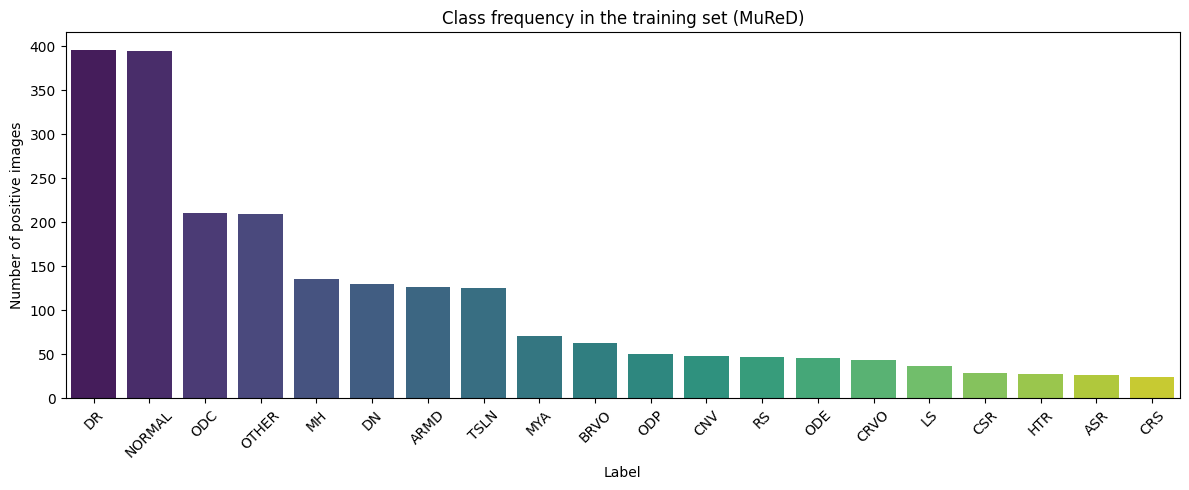

This bar chart makes the class imbalance explicit: DR/NORMAL/ODC/OTHER dominate, while labels like CRS, ASR, HTR, CSR have very few positive examples. This directly motivates (a) using AUROC/F1 instead of accuracy, and (b) a class-imbalance-aware loss (binary focal loss) in Section 6/7.


In [27]:
plt.figure(figsize=(12, 5))
sns.barplot(x=label_counts.index, y=label_counts.values,
            hue=label_counts.index, palette="viridis", legend=False)
plt.title("Class frequency in the training set (MuReD)")
plt.ylabel("Number of positive images")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("This bar chart makes the class imbalance explicit: DR/NORMAL/ODC/OTHER dominate, "
      "while labels like CRS, ASR, HTR, CSR have very few positive examples. This directly "
      "motivates (a) using AUROC/F1 instead of accuracy, and (b) a class-imbalance-aware loss "
      "(binary focal loss) in Section 6/7.")


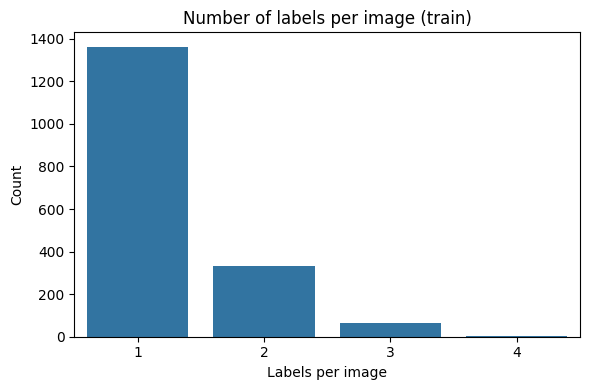

count    1764.000000
mean        1.269841
std         0.534438
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
dtype: float64


In [28]:
cardinality = train_df[label_cols].sum(axis=1)

plt.figure(figsize=(6, 4))
sns.countplot(x=cardinality)
plt.title("Number of labels per image (train)")
plt.xlabel("Labels per image")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(cardinality.describe())


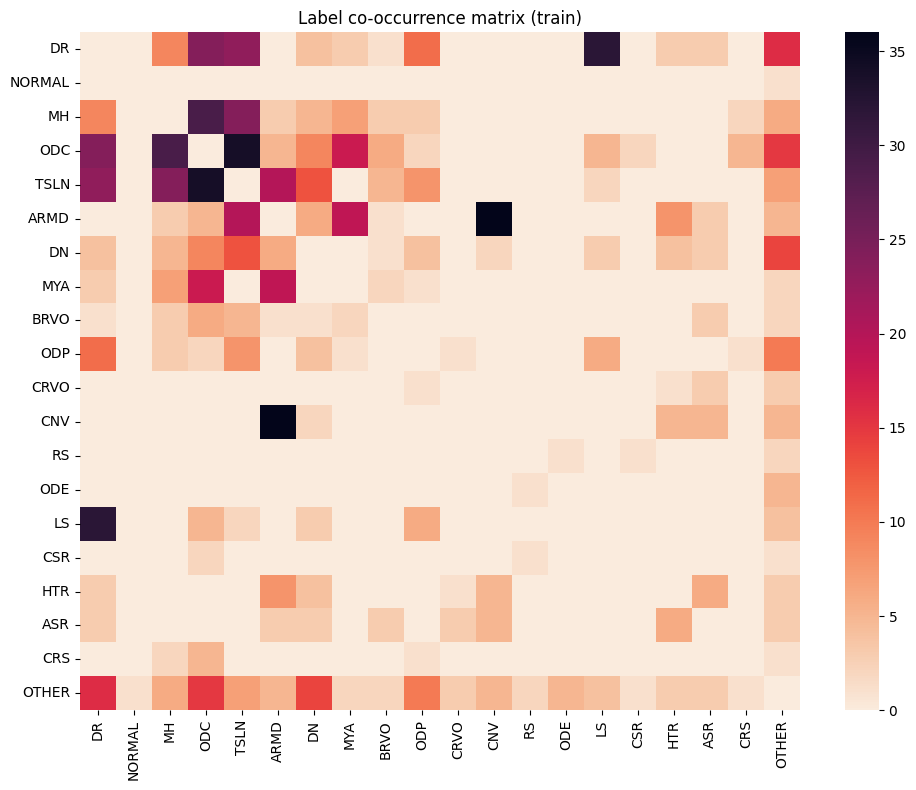

In [29]:
co_occurrence = train_df[label_cols].T.dot(train_df[label_cols])
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, cmap="rocket_r", annot=False)
plt.title("Label co-occurrence matrix (train)")
plt.tight_layout()
plt.show()


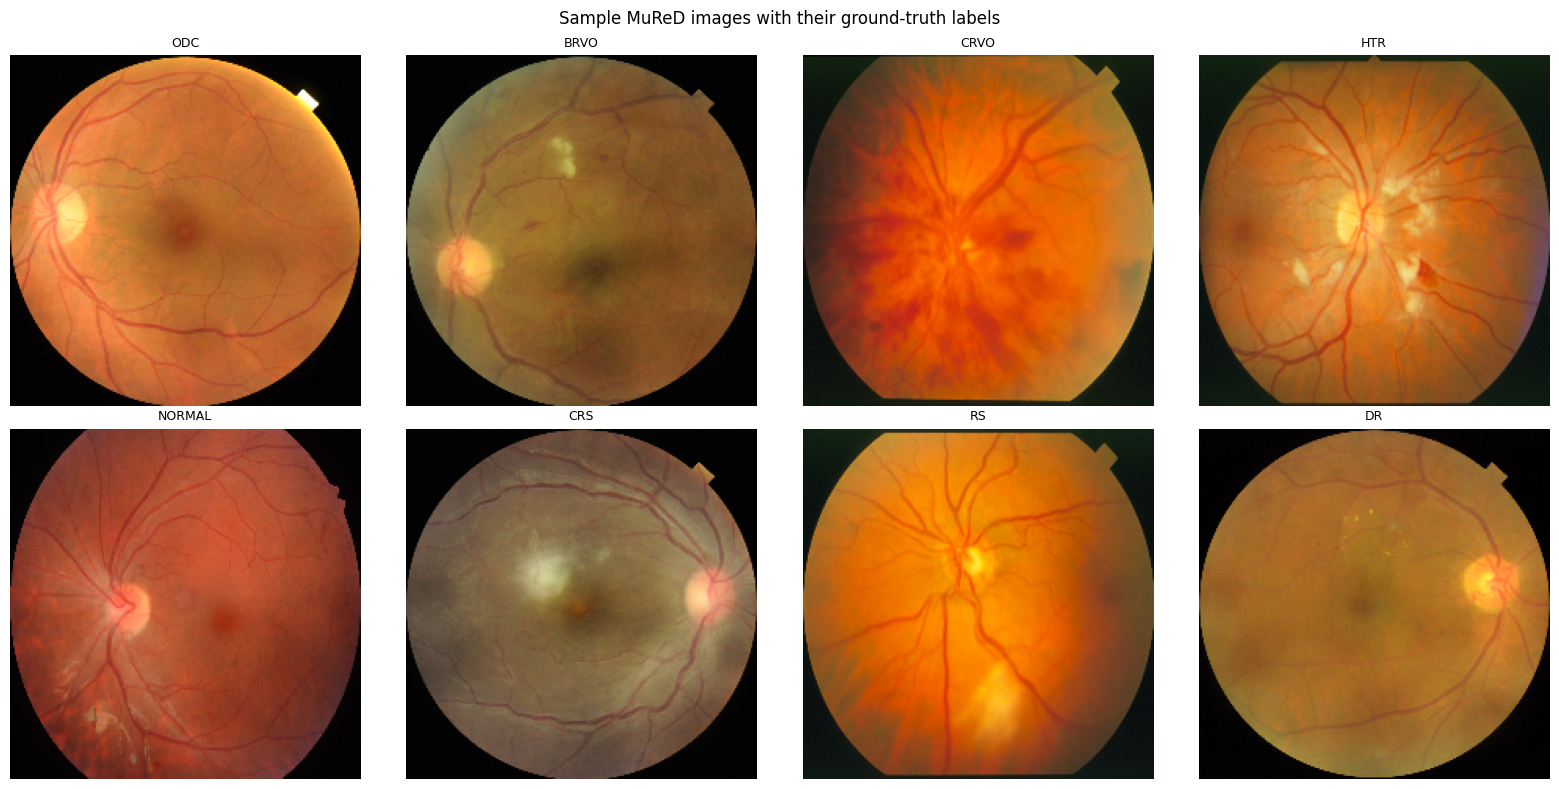

In [30]:
def load_image_for_display(path, size=IMG_SIZE):
    img = tf.io.read_file(path)
    try:
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(path).convert("RGB"))
        img = tf.convert_to_tensor(img)
    img = tf.image.resize(img, (size, size))
    return tf.cast(img, tf.uint8).numpy()


sample_rows = train_df.sample(
    n=min(8, len(train_df)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    try:
        img = load_image_for_display(row["filepath"])
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, f"Could not load:\n{e}",
                ha="center", va="center", wrap=True)
    present_labels = [c for c in label_cols if row[c] == 1]
    ax.set_title(", ".join(present_labels), fontsize=9)
    ax.axis("off")
plt.suptitle("Sample MuReD images with their ground-truth labels")
plt.tight_layout()
plt.show()


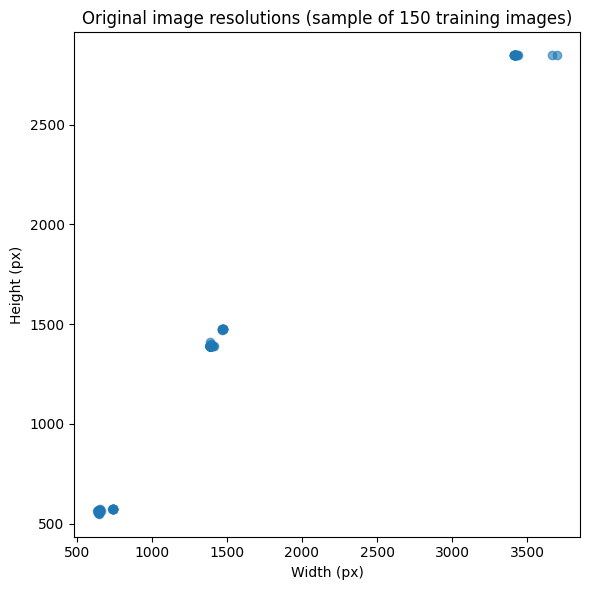

Because resolution varies so much, every image is resized to 224x224 in the input pipeline (Section 5) before being fed to the CNN.


In [31]:
from PIL import Image

sizes = []
for p in train_df["filepath"].sample(n=min(150, len(train_df)), random_state=SEED):
    with Image.open(p) as im:
        sizes.append(im.size)  # (width, height)

sizes = np.array(sizes)
plt.figure(figsize=(6, 6))
plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.6)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Original image resolutions (sample of 150 training images)")
plt.tight_layout()
plt.show()

print("Because resolution varies so much, every image is resized to "
      f"{IMG_SIZE}x{IMG_SIZE} in the input pipeline (Section 5) before being fed to the CNN.")


In [32]:
X_ids = val_df["ID"].values
Y = val_df[label_cols].values

if HAS_ITERSTRAT:
    msss = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=0.5, random_state=SEED)
    val_idx, test_idx = next(msss.split(X_ids, Y))
else:
    val_idx, test_idx = train_test_split(
        np.arange(len(val_df)), test_size=0.5, random_state=SEED, shuffle=True
    )

val_final_df = val_df.iloc[val_idx].reset_index(drop=True)
test_final_df = val_df.iloc[test_idx].reset_index(drop=True)

print("Final split sizes:")
print(f"  train : {len(train_df)} images")
print(f"  val   : {len(val_final_df)} images")
print(f"  test  : {len(test_final_df)} images")

split_check = pd.DataFrame({
    "val_positives":  val_final_df[label_cols].sum(),
    "test_positives": test_final_df[label_cols].sum(),
})
split_check


Final split sizes:
  train : 1764 images
  val   : 222 images
  test  : 222 images


,val_positives,test_positives
DR,50,49
NORMAL,49,49
MH,17,17
ODC,26,26
TSLN,15,16
ARMD,16,16
DN,16,16
MYA,9,9
BRVO,8,8
ODP,6,6


In [33]:
def _load_image_py(path):
    path = path.numpy().decode("utf-8")
    try:
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(
            raw, channels=3, expand_animations=False).numpy()
    except Exception:
        from PIL import Image
        img = np.array(Image.open(path).convert("RGB"))
    return img.astype(np.float32)


def load_and_preprocess(path, label):
    img = tf.py_function(func=_load_image_py, inp=[path], Tout=tf.float32)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = applications.efficientnet.preprocess_input(img)
    return img, label


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")


def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df[label_cols].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(
            x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_final_df, training=False)
test_ds = make_dataset(test_final_df, training=False)

for imgs, labels in train_ds.take(1):
    print("Batch image shape:", imgs.shape,
          " Batch label shape:", labels.shape)


Batch image shape: (16, 224, 224, 3)  Batch label shape: (16, 20)


In [34]:
def build_model(backbone_type="efficientnet", num_classes=NUM_CLASSES, img_size=IMG_SIZE, trainable_backbone=False):
    inputs = layers.Input(shape=(img_size, img_size, 3))

    if backbone_type == "efficientnet":
        base_model = applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3), pooling=None)
    elif backbone_type == "resnet":
        base_model = applications.ResNet50(
            include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3), pooling=None)
    elif backbone_type == "densenet":
        base_model = applications.DenseNet121(
            include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3), pooling=None)
    else:
        raise ValueError("Invalid backbone type")

    base_model.trainable = trainable_backbone
    x = base_model(inputs, training=trainable_backbone)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name=f"mured_{backbone_type}")
    return model, base_model


def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryFocalCrossentropy(
            apply_class_balancing=True, gamma=2.0),
        metrics=[
            tf.keras.metrics.AUC(
                multi_label=True, num_labels=NUM_CLASSES, name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model




In [37]:
import json as _json

backbones = ["efficientnet", "resnet", "densenet"]
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10

trained_models = {}

for bb in backbones:
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{bb}.weights.h5")
    history_path = os.path.join(CHECKPOINT_DIR, f"history_{bb}.json")

    if os.path.exists(ckpt_path):
        print(f"\n{bb}: found an existing checkpoint at {ckpt_path} -- skipping retraining. "
              f"Delete this file (and {history_path}, if you want fresh curves) to retrain {bb}.")
        model, base_model = build_model(backbone_type=bb)
        model.load_weights(ckpt_path)
        trained_models[bb] = model
        continue

    print(f"\n{'='*50}\nTraining Backbone: {bb.upper()}\n{'='*50}")

    # Phase 1: Frozen Backbone
    print(f"Phase 1: Training top layers for {bb}...")
    model, base_model = build_model(backbone_type=bb, trainable_backbone=False)
    model = compile_model(model, lr=1e-3)

    callbacks_p1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True),
    ]

    hist_1 = model.fit(train_ds, validation_data=val_ds,
                       epochs=EPOCHS_PHASE1, callbacks=callbacks_p1)

    # Phase 2: Fine-tuning
    print(f"\nPhase 2: Fine-tuning entire {bb}...")
    base_model.trainable = True
    model = compile_model(model, lr=1e-5)

    callbacks_p2 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True),
    ]

    hist_2 = model.fit(train_ds, validation_data=val_ds,
                       epochs=EPOCHS_PHASE2, callbacks=callbacks_p2)

    # Persist combined history so it survives disconnects and future resumed runs
    combined_history = {"phase1_epochs": len(hist_1.history["loss"])}
    for k in hist_1.history.keys():
        combined_history[k] = hist_1.history[k] + hist_2.history[k]
    with open(history_path, "w") as f:
        _json.dump(combined_history, f)
    print(f"Saved training history to {history_path}")

    # Save the final best model in dictionary for evaluation
    trained_models[bb] = model



efficientnet: found an existing checkpoint at /content/drive/MyDrive/Multi-Label Retinal Diseases (MuReD) Dataset/checkpoints/best_efficientnet.weights.h5 -- skipping retraining. Delete this file (and /content/drive/MyDrive/Multi-Label Retinal Diseases (MuReD) Dataset/checkpoints/history_efficientnet.json, if you want fresh curves) to retrain efficientnet.

Training Backbone: RESNET
Phase 1: Training top layers for resnet...
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 602s 4s/step - auc: 0.5631 - loss: 0.1713 - precision: 0.0839 - recall: 0.4647 - val_auc: 0.7772 - val_loss: 0.0524 - val_precision: 0.2773 - val_recall: 0.2545 - learning_rate: 0.0010
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 630s 4s/step - auc: 0.6168 - loss: 0.0337 - precision: 0.2086 - recall: 0.1317 - val_auc: 0.8611 - val_loss: 0.0162 - val_precision: 0.8333 - val_recall: 0.0896 - learning_rate: 0.0010
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 609s 4s/step - auc: 0.6711 - loss: 0.0220 - precision: 0.4951 - recall: 0.0911 -

## Training Curves

Loss and AUC over epochs for the EfficientNet backbone (the primary model), read back from the
history file saved during training. The vertical dashed line marks where Phase 2 (fine-tuning)
begins.

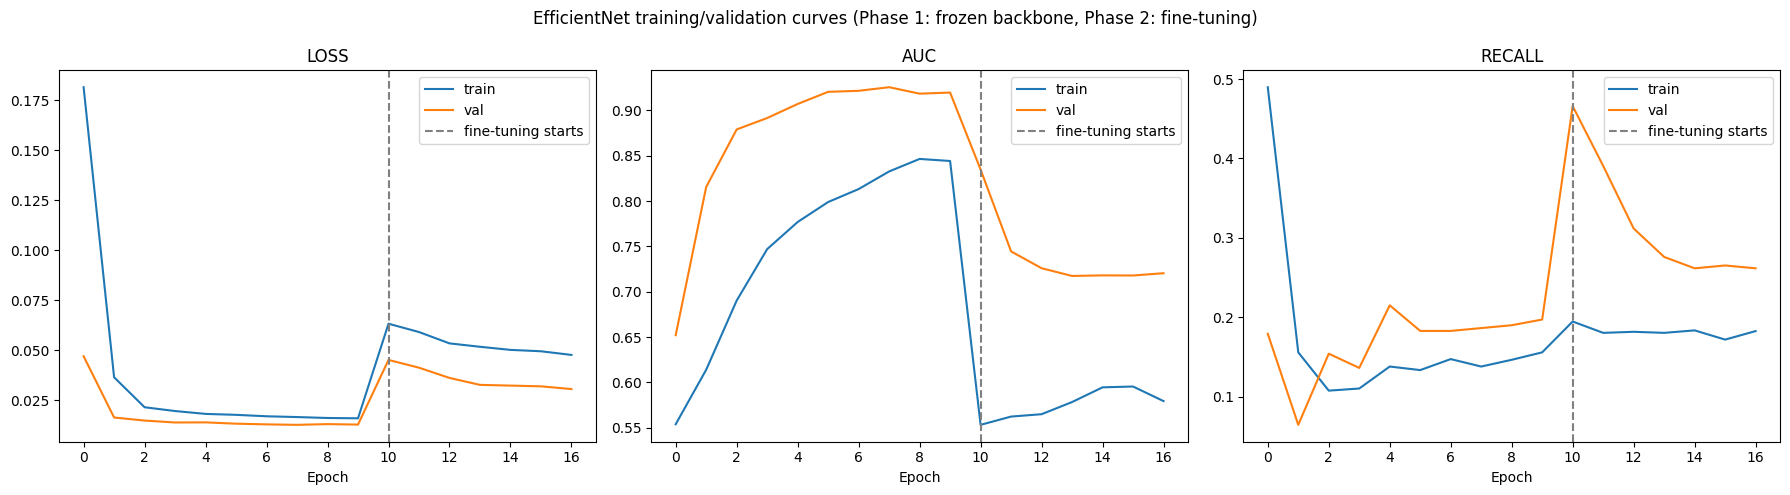

In [41]:
import json
history_path = os.path.join(CHECKPOINT_DIR, "history_efficientnet.json")

if os.path.exists(history_path):
    with open(history_path) as f:
        hist = json.load(f)
    phase_boundary = hist.pop("phase1_epochs")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, ["loss", "auc", "recall"]):
        ax.plot(hist[metric], label="train")
        ax.plot(hist[f"val_{metric}"], label="val")
        ax.axvline(phase_boundary, color="gray", linestyle="--", label="fine-tuning starts")
        ax.set_title(metric.upper())
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.suptitle("EfficientNet training/validation curves (Phase 1: frozen backbone, Phase 2: fine-tuning)")
    plt.tight_layout()
    plt.show()
else:
    print(f"No saved training history found at {history_path}.")
    print("This happens when the checkpoint already existed and every run so far has resumed from it")
    print("instead of retraining. To generate real curves for submission: delete")
    print(f"  {os.path.join(CHECKPOINT_DIR, 'best_efficientnet.weights.h5')}")
    print("and re-run the training cell above -- it will retrain from scratch and save history this time.")


## Model Evaluation: Threshold Calibration & Single-Model vs. Ensemble


In [42]:
from sklearn.metrics import roc_curve, auc, f1_score, hamming_loss, classification_report, roc_auc_score
import numpy as np

MIN_SUPPORT = 10  # classes with fewer than this many positive (or negative) validation examples
                   # get a fixed 0.5 threshold instead of a per-class "optimal" one -- see markdown above


def compute_metrics(y_true_val, y_proba_val, y_true_test, y_proba_test, label_cols, min_support=MIN_SUPPORT):
    """Per-class threshold selection (with a min-support guard) + the full metric suite."""
    thresholds = []
    for i in range(len(label_cols)):
        n_pos = int(y_true_val[:, i].sum())
        n_neg = len(y_true_val) - n_pos
        if n_pos < min_support or n_neg < min_support:
            thresholds.append(0.5)
            continue
        fpr, tpr, thr = roc_curve(y_true_val[:, i], y_proba_val[:, i])
        j_stat = tpr - fpr
        thresholds.append(thr[np.argmax(j_stat)])
    thresholds = np.array(thresholds)

    y_pred_test = (y_proba_test >= thresholds).astype(int)

    macro_f1 = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true_test, y_pred_test, average="micro", zero_division=0)
    h_loss = hamming_loss(y_true_test, y_pred_test)

    auroc_per_class = {}
    for i, c in enumerate(label_cols):
        if len(np.unique(y_true_test[:, i])) > 1:
            auroc_per_class[c] = roc_auc_score(y_true_test[:, i], y_proba_test[:, i])
    macro_auroc = np.mean(list(auroc_per_class.values())) if auroc_per_class else float("nan")

    report = classification_report(y_true_test, y_pred_test, target_names=label_cols, zero_division=0)

    return {
        "thresholds": thresholds,
        "y_pred_test": y_pred_test,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "hamming_loss": h_loss,
        "macro_auroc": macro_auroc,
        "auroc_per_class": auroc_per_class,
        "report": report,
    }


print("Generating predictions from all ensemble models...")
y_true_val = val_final_df[label_cols].values
y_true_test = test_final_df[label_cols].values

ensemble_val_preds = []
ensemble_test_preds = []

for bb in backbones:
    print(f"Predicting with {bb}...")
    model, _ = build_model(backbone_type=bb)
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{bb}.weights.h5")
    try:
        model.load_weights(ckpt_path)
    except Exception as e:
        print(f"Warning: Could not load weights for {bb} ({e}). Using current state.")

    ensemble_val_preds.append(model.predict(val_ds))
    ensemble_test_preds.append(model.predict(test_ds))

# Ensemble (soft-voting average across all backbones) ----
y_pred_proba_val = np.mean(ensemble_val_preds, axis=0)
y_pred_proba_test = np.mean(ensemble_test_preds, axis=0)
ensemble_results = compute_metrics(y_true_val, y_pred_proba_val, y_true_test, y_pred_proba_test, label_cols)

# Single model (EfficientNet only) for comparison ----
eff_idx = backbones.index("efficientnet")
single_results = compute_metrics(
    y_true_val, ensemble_val_preds[eff_idx], y_true_test, ensemble_test_preds[eff_idx], label_cols)

print("\n" + "=" * 60)
print("SINGLE MODEL (EfficientNet only) vs 3-BACKBONE ENSEMBLE")
print("=" * 60)
comparison = pd.DataFrame({
    "EfficientNet only": [single_results["macro_f1"], single_results["micro_f1"],
                           single_results["hamming_loss"], single_results["macro_auroc"]],
    "3-model Ensemble":  [ensemble_results["macro_f1"], ensemble_results["micro_f1"],
                           ensemble_results["hamming_loss"], ensemble_results["macro_auroc"]],
}, index=["Macro-F1", "Micro-F1", "Hamming Loss", "Macro-AUROC"])
print(comparison.round(4))
print("\nThis is the actual justification for the ensemble's extra training cost: if the ensemble")
print("column isn't meaningfully better than the single-model column, the 3x training time spent")
print("on ResNet50 and DenseNet121 isn't earning its keep for this dataset/task.")

print("\nThresholds used for the ENSEMBLE (0.5 = fell back to default; class had <", MIN_SUPPORT,
      "positive or negative examples in the validation split):")
for c, t in zip(label_cols, ensemble_results["thresholds"]):
    flag = "  <- fallback (insufficient val support)" if np.isclose(t, 0.5) else ""
    print(f"{c.ljust(10)}: {t:.4f}{flag}")

macro_f1, micro_f1, h_loss, macro_auroc = (ensemble_results["macro_f1"], ensemble_results["micro_f1"],
                                            ensemble_results["hamming_loss"], ensemble_results["macro_auroc"])
auroc_per_class = ensemble_results["auroc_per_class"]
y_pred_test = ensemble_results["y_pred_test"]

print(f"\nEnsemble Macro-F1     : {macro_f1:.4f}")
print(f"Ensemble Micro-F1     : {micro_f1:.4f}")
print(f"Ensemble Hamming loss : {h_loss:.4f}")
print(f"Ensemble Macro-AUROC  : {macro_auroc:.4f}")

print("\nEnsemble Classification Report (thresholds guarded against tiny-sample overfitting):")
print(ensemble_results["report"])


Generating predictions from all ensemble models...
Predicting with efficientnet...
14/14 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step
Predicting with resnet...
14/14 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step
Predicting with densenet...
14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step

SINGLE MODEL (EfficientNet only) vs 3-BACKBONE ENSEMBLE
              EfficientNet only  3-model Ensemble
Macro-F1                 0.2637            0.2542
Micro-F1                 0.3343            0.4596
Hamming Loss             0.1579            0.0980
Macro-AUROC              0.8268            0.8944

This is the actual justification for the ensemble's extra training cost: if the ensemble
column isn't meaningfully better than the single-model column, the 3x training time spent
on ResNet50 and DenseNet121 isn't earning its keep for this dataset/task.

Thresholds used for the ENSEMBLE (0.5 = fell back to default; class

## Phase 3: Explainable AI with Grad-CAM


In [43]:
# ---- Phase 3: Explainable AI with Grad-CAM ----
import matplotlib.cm as cm


def get_img_array(img_path, size):
    # Load and preprocess image for Grad-CAM
    img = load_image_for_display(img_path, size=size)
    img_array = tf.cast(img, tf.float32)
    img_array = applications.efficientnet.preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0), img


def make_gradcam_heatmap(img_array, model, base_model, pred_index=None):
    head_layers = [layer for layer in model.layers
                   if layer is not base_model and not isinstance(layer, tf.keras.layers.InputLayer)]

    with tf.GradientTape() as tape:
        conv_output = base_model(img_array, training=False)
        tape.watch(conv_output)

        x = conv_output
        for layer in head_layers:
            x = layer(x, training=False)
        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the predicted class' sigmoid output w.r.t. the last conv feature map
    grads = tape.gradient(class_channel, conv_output)

    # Average gradients spatially -> importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the pooled gradients
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def display_gradcam(img_path, heatmap, alpha=0.4):
    img = load_image_for_display(img_path, size=IMG_SIZE)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img)
    return superimposed_img

Loaded best model weights from /content/drive/MyDrive/Multi-Label Retinal Diseases (MuReD) Dataset/checkpoints/best_efficientnet.weights.h5 for Grad-CAM visualization.


/tmp/ipykernel_25371/3973954807.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


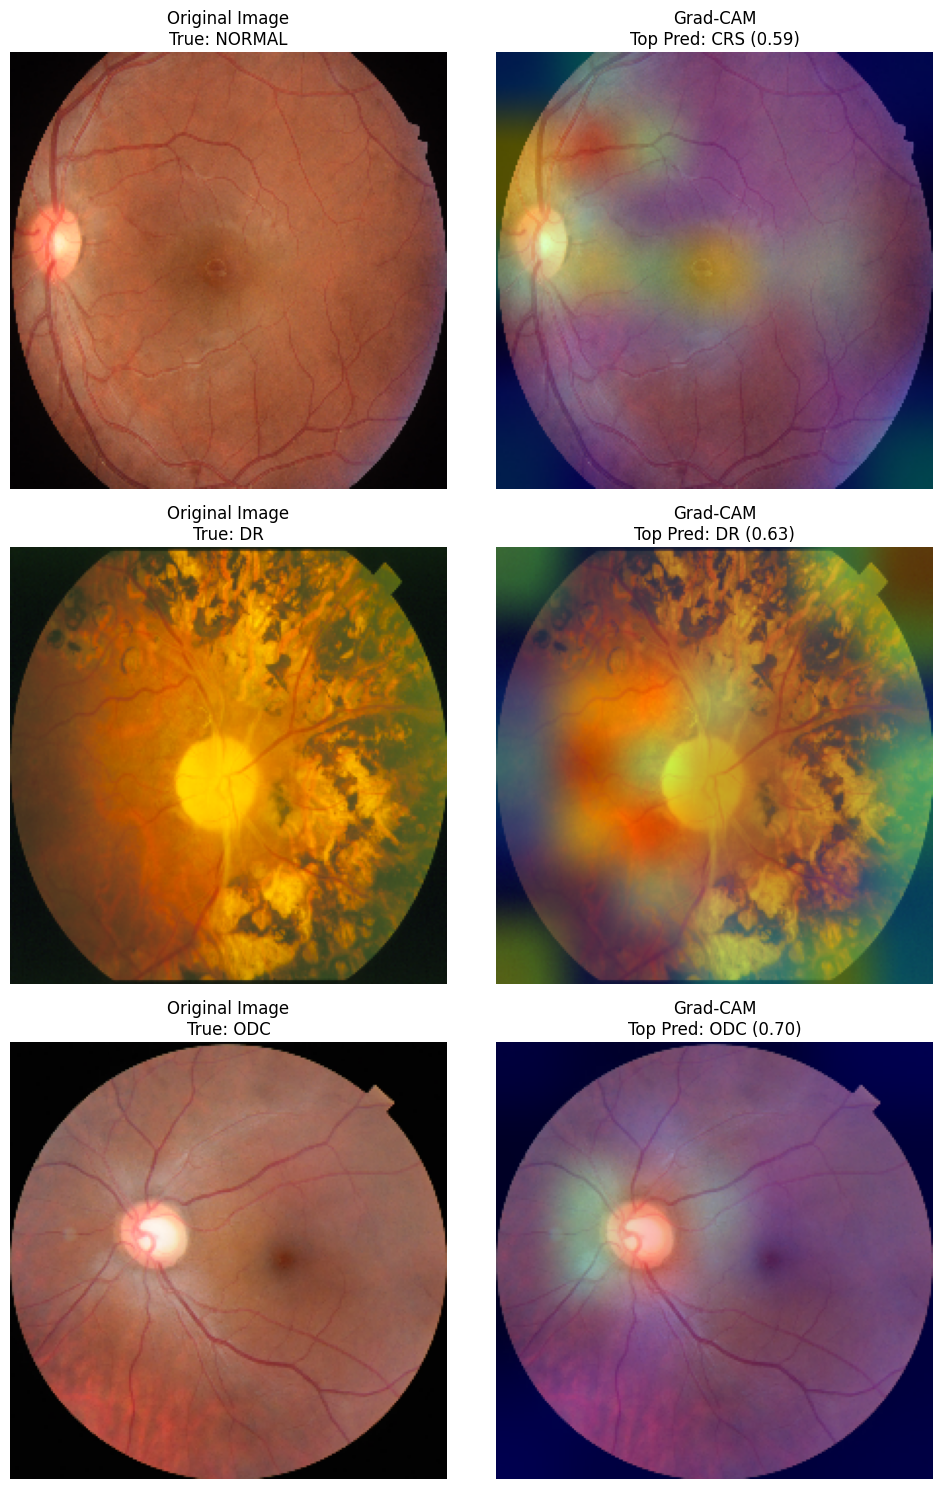

In [44]:
# Load the best EfficientNet model weights for Grad-CAM visualization
model, base_model = build_model("efficientnet")
ckpt_path = os.path.join(CHECKPOINT_DIR, "best_efficientnet.weights.h5")
try:
    model.load_weights(ckpt_path)
    print(f"Loaded best model weights from {ckpt_path} for Grad-CAM visualization.")
except Exception as e:
    print(f"Could not load {ckpt_path} ({e}); using current in-memory model state instead.")

# Select a few images from the test set to visualize
sample_test = test_final_df.sample(n=3, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, row in sample_test.iterrows():
    img_path = row["filepath"]
    true_labels = [c for c in label_cols if row[c] == 1]

    img_array, orig_img = get_img_array(img_path, size=IMG_SIZE)

    heatmap, top_pred_idx = make_gradcam_heatmap(img_array, model, base_model)
    preds = model.predict(img_array, verbose=0)[0]
    predicted_class = CLASS_NAMES[top_pred_idx]

    cam_img = display_gradcam(img_path, heatmap)

    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original Image\nTrue: {', '.join(true_labels)}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam_img)
    axes[i, 1].set_title(
        f"Grad-CAM\nTop Pred: {predicted_class} ({preds[top_pred_idx]:.2f})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()